# Project 1: EDA & Visualization on Diabetes Dataset

**Objective:** Practice data loading, visualization, and EDA using Python on a real dataset.

**Deliverables:** Plots, measurements, observations, and focused comparisons.


In [7]:
# Import libraries
import pandas as pd  # tabular data handling
import numpy as np   # numerical operations
import matplotlib.pyplot as plt  # plotting (matplotlib only for this notebook)
from pandas.plotting import scatter_matrix  # pairwise scatter plots

# The above imports follow the lecture pattern: pandas for data, numpy for math,
# matplotlib for visualization, and scatter_matrix for pairwise plots.


In [8]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('diabetes.csv')  # reads the CSV file shipped with the project
df.head()  # preview the first 5 rows to confirm columns and values

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
# Inspect basic structure
rows, cols = df.shape           # (number of rows, number of columns)
print('Shape:', rows, 'rows x', cols, 'columns')
print('Columns:', list(df.columns))
df.select_dtypes(include=[np.number]).describe()  # quick numeric summary (count, mean, std, quartiles)

Shape: 768 rows x 9 columns
Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Part 2: Visualizations

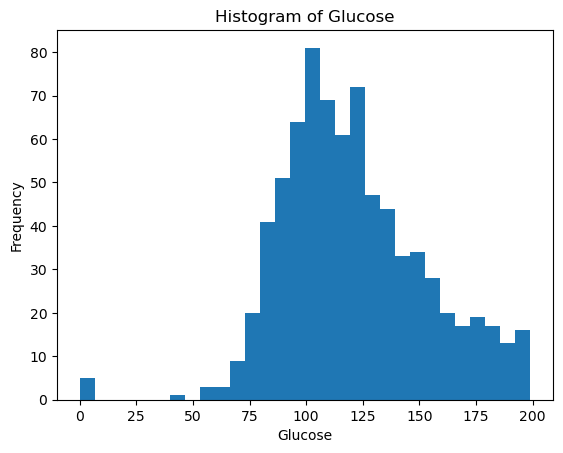

In [10]:
# 1) Histogram of Glucose
plt.figure()
plt.hist(df['Glucose'].dropna(), bins=30)  # histogram using 30 bins for detail
plt.title('Histogram of Glucose')
plt.xlabel('Glucose')
plt.ylabel('Frequency')
plt.show()

# Line-by-line:
# - plt.figure(): start a new figure
# - plt.hist(...): draw histogram of 'Glucose' values, ignoring missing
# - plt.title/xlabel/ylabel: annotate the plot
# - plt.show(): render the plot in the notebook

C:\Users\lawra\AppData\Local\Temp\ipykernel_1320\1933748861.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df['BMI'].dropna(), vert=True, labels=['BMI'])


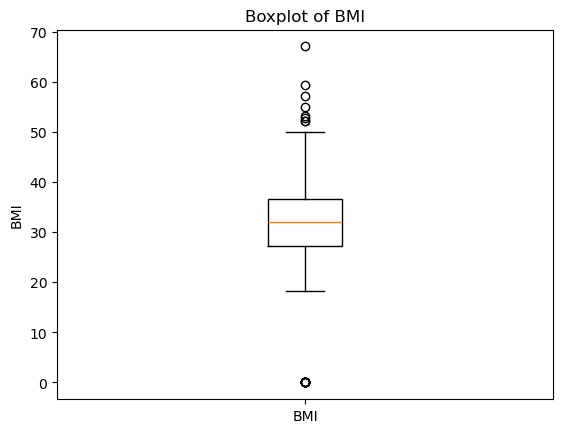

In [11]:
# 2) Boxplot of BMI
plt.figure()
plt.boxplot(df['BMI'].dropna(), vert=True, labels=['BMI'])
plt.title('Boxplot of BMI')
plt.ylabel('BMI')
plt.show()

# Boxplots summarize spread (IQR) and highlight outliers.

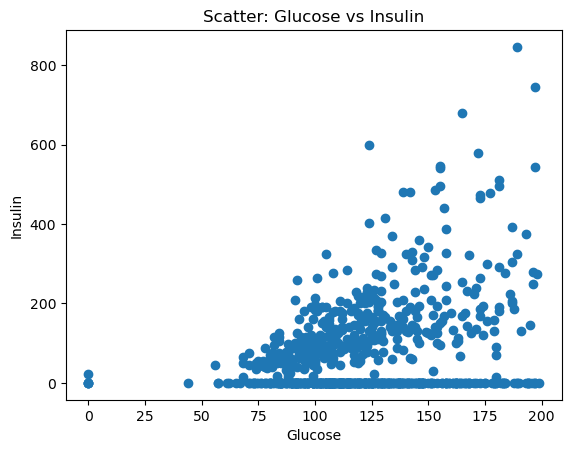

In [12]:
# 3) Scatter: Glucose vs Insulin
plt.figure()
plt.scatter(df['Glucose'], df['Insulin'])
plt.title('Scatter: Glucose vs Insulin')
plt.xlabel('Glucose')
plt.ylabel('Insulin')
plt.show()

# Scatter plots reveal potential relationships between two numeric variables.

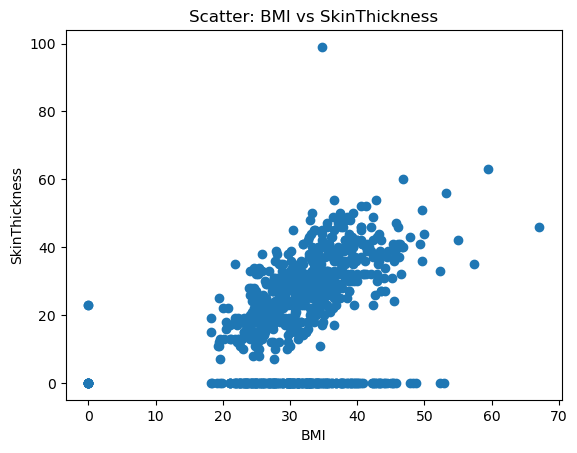

In [13]:
# 4) Scatter: BMI vs SkinThickness
plt.figure()
plt.scatter(df['BMI'], df['SkinThickness'])
plt.title('Scatter: BMI vs SkinThickness')
plt.xlabel('BMI')
plt.ylabel('SkinThickness')
plt.show()

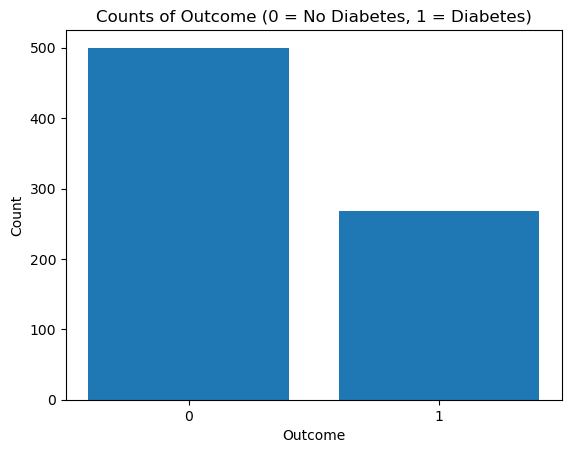

In [14]:
# 5) Outcome counts (bar chart)
plt.figure()
counts = df['Outcome'].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.title('Counts of Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

# This is analogous to a count plot: it shows how many rows per class.

## Part 3: EDA Measurements

In [15]:
# Select only numeric columns for statistical calculations
num_df = df.select_dtypes(include=[np.number])

# Central tendency
mean_s = num_df.mean()      # column-wise mean
median_s = num_df.median()  # column-wise median

# Range and IQR
range_s = num_df.max() - num_df.min()  # max - min
q1 = num_df.quantile(0.25)             # first quartile
q3 = num_df.quantile(0.75)             # third quartile
iqr_s = q3 - q1                         # interquartile range

# Variance & Standard Deviation
var_s = num_df.var()
std_s = num_df.std()

# Covariance & Correlation matrices
cov_m = num_df.cov()
corr_m = num_df.corr()

stats_table = pd.DataFrame({
    'Mean': mean_s,
    'Median': median_s,
    'Range': range_s,
    'IQR': iqr_s,
    'Variance': var_s,
    'StdDev': std_s
})
stats_table.round(3)

,Mean,Median,Range,IQR,Variance,StdDev
Pregnancies,3.845,3.000,17.000,5.000,11.354,3.370
Glucose,120.895,117.000,199.000,41.250,1022.248,31.973
BloodPressure,69.105,72.000,122.000,18.000,374.647,19.356
SkinThickness,20.536,23.000,99.000,32.000,254.473,15.952
Insulin,79.799,30.500,846.000,127.250,13281.180,115.244
BMI,31.993,32.000,67.100,9.300,62.160,7.884
DiabetesPedigreeFunction,0.472,0.372,2.342,0.382,0.110,0.331
Age,33.241,29.000,60.000,17.000,138.303,11.760
Outcome,0.349,0.000,1.000,1.000,0.227,0.477


## Part 4: Correlation Analysis

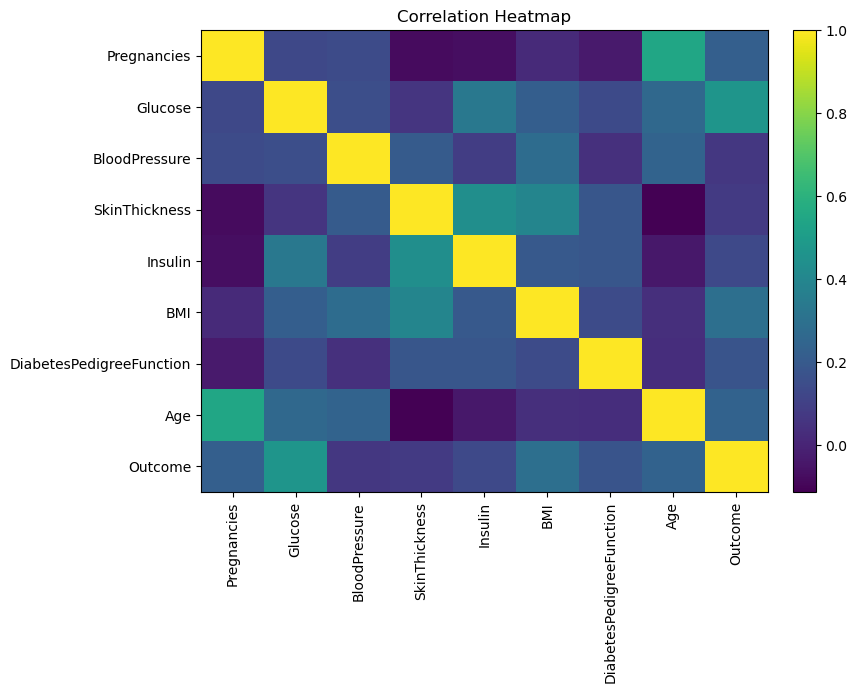

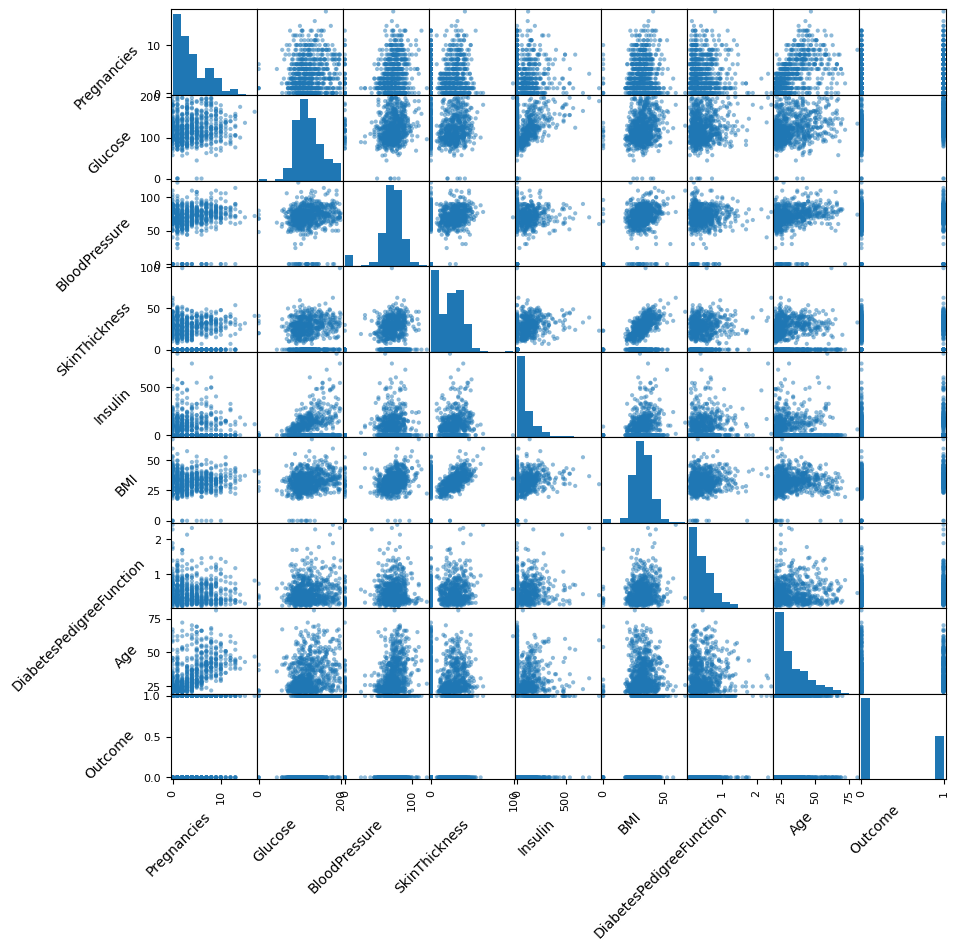

In [16]:
# Correlation heatmap (matplotlib imshow)
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
im = plt.imshow(corr, aspect='auto')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Heatmap')
plt.show()

# Pairwise scatter matrix (pairplot analog)
axs = scatter_matrix(df.select_dtypes(include=[np.number]), figsize=(10,10), diagonal='hist')
for ax in axs.ravel():
    ax.set_xlabel(ax.get_xlabel(), rotation=45, ha='right')
    ax.set_ylabel(ax.get_ylabel(), rotation=45, ha='right')
plt.show()

## Focused Comparisons: Glucose & Age; BMI & Diabetes

In [17]:
# Compare group means for key risk factors by Outcome
group_means = df.groupby('Outcome')[['Glucose','Age','BMI','DiabetesPedigreeFunction']].mean().round(2)
group_means

,Glucose,Age,BMI,DiabetesPedigreeFunction
Outcome,,,,
0,109.98,31.19,30.30,0.43
1,141.26,37.07,35.14,0.55


C:\Users\lawra\AppData\Local\Temp\ipykernel_1320\2563689987.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df['Outcome']==0]['Glucose'].dropna(),


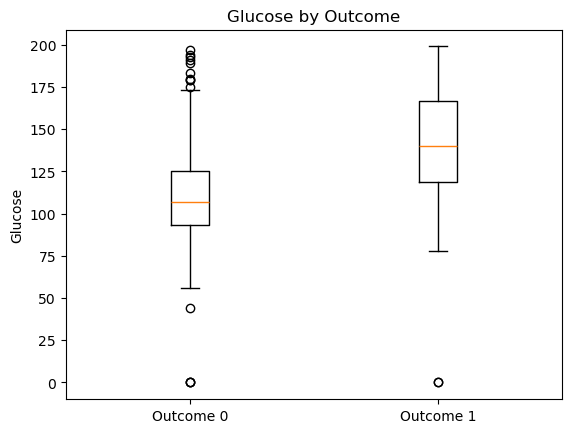

C:\Users\lawra\AppData\Local\Temp\ipykernel_1320\2563689987.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df['Outcome']==0]['Age'].dropna(),


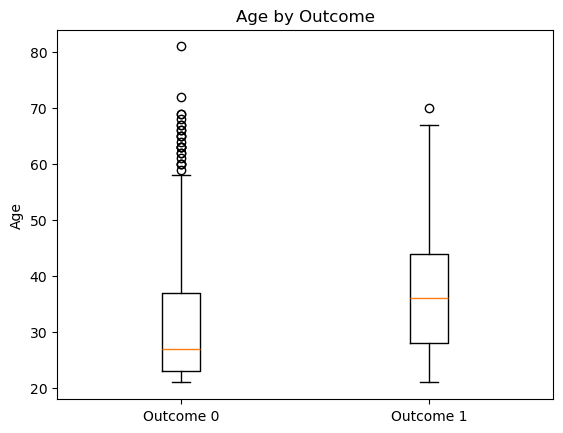

In [18]:
# Boxplots: Glucose and Age by Outcome
plt.figure()
plt.boxplot([df[df['Outcome']==0]['Glucose'].dropna(),
             df[df['Outcome']==1]['Glucose'].dropna()], labels=['Outcome 0','Outcome 1'])
plt.title('Glucose by Outcome')
plt.ylabel('Glucose')
plt.show()

plt.figure()
plt.boxplot([df[df['Outcome']==0]['Age'].dropna(),
             df[df['Outcome']==1]['Age'].dropna()], labels=['Outcome 0','Outcome 1'])
plt.title('Age by Outcome')
plt.ylabel('Age')
plt.show()

# Interpretation (inline comments):
# - Higher Glucose in Outcome=1 indicates strong association with diabetes.
# - Higher Age in Outcome=1 suggests risk increases with age.

C:\Users\lawra\AppData\Local\Temp\ipykernel_1320\2195602341.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df['Outcome']==0]['BMI'].dropna(),


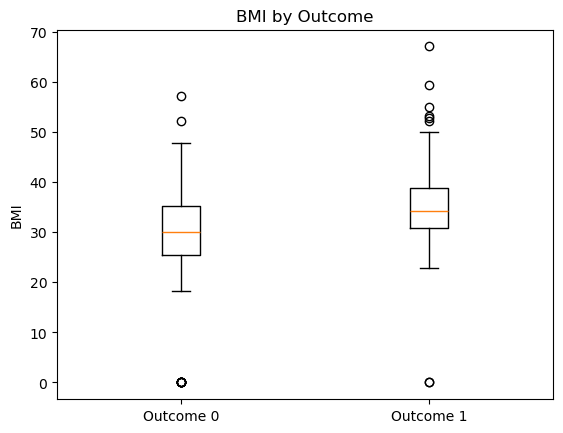

In [19]:
# Boxplot: BMI vs Outcome
plt.figure()
plt.boxplot([df[df['Outcome']==0]['BMI'].dropna(),
             df[df['Outcome']==1]['BMI'].dropna()], labels=['Outcome 0','Outcome 1'])
plt.title('BMI by Outcome')
plt.ylabel('BMI')
plt.show()

# Interpretation (inline comments):
# - Median BMI tends to be higher for Outcome=1, aligning with obesity as a risk factor.